In [1]:
import rebound
import reboundx
import numpy as np

# Simulation settings
C_LIGHT = 457.14
ENABLE_2PN = 0
ENABLE_25PN = 1
T_END = 4.2
N_SAMPLES = 80

# Initial conditions for the two bodies:
# (mass, x, y, z, vx, vy, vz)
body_1 = (
    1.00000001e-01,
    -2.86636483e00, -3.51352660e00, 1.31048588e00,
    -8.29922019e00, -2.77660036e00, -1.16069792e-01,
)

body_2 = (
    5.99999987e-02,
    -2.86626798e00, -3.51381408e00, 1.31048970e00,
    1.38346340e01, 4.61131049e00, 1.91195042e-01,
)

# Create the simulation
sim = rebound.Simulation()
sim.G = 1
sim.integrator = "ias15"

# Add the two particles
sim.add(
    m=body_1[0],
    x=body_1[1], y=body_1[2], z=body_1[3],
    vx=body_1[4], vy=body_1[5], vz=body_1[6],
)
sim.add(
    m=body_2[0],
    x=body_2[1], y=body_2[2], z=body_2[3],
    vx=body_2[4], vy=body_2[5], vz=body_2[6],
)

# Shift to the center-of-momentum frame
sim.move_to_com()

# Reference the second particle for convenience
secondary = sim.particles[1]

# Attach REBOUNDx and add post-Newtonian corrections
rebx = reboundx.Extras(sim)
pn_force = rebx.load_force("post_newtonian")
rebx.add_force(pn_force)

# Configure which PN terms are enabled
pn_force.params["pn_2PN"] = ENABLE_2PN
pn_force.params["pn_25PN"] = ENABLE_25PN
pn_force.params["c"] = C_LIGHT

# Store time and semimajor axis during the integration
time_array = []
a_array = []

# Integrate and print the instantaneous separation at each sample time 
for t in np.linspace(0.0, T_END, N_SAMPLES) :
    sim.integrate(t)

    dx = sim.particles[0].x - sim.particles[1].x
    dy = sim.particles[0].y - sim.particles[1].y
    dz = sim.particles[0].z - sim.particles[1].z
    separation = np.sqrt(dx**2 + dy**2 + dz**2)
    time_array.append(sim.t)
    a_array.append(secondary.a)

/home/mad/anaconda3/envs/rbx2025/lib/python3.13/site-packages/rebound/simulation.py:259: RuntimeWarning: At least 10 predictor corrector loops in IAS15 did not converge. This is typically an indication of the timestep being too large.
  warnings.warn(msg[1:], RuntimeWarning)


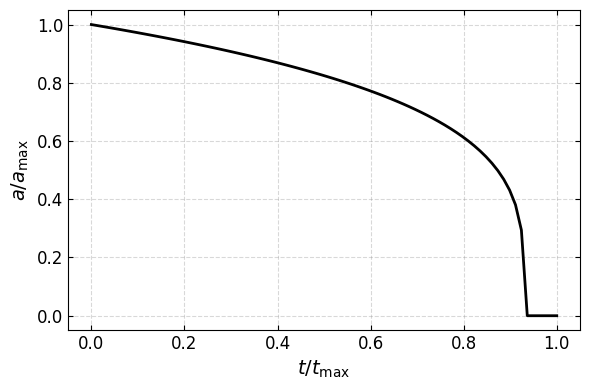

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(time_array/(np.nanmax(time_array)+1e-20),np.nan_to_num(a_array/(np.nanmax(a_array))),c='black',lw=2)

plt.xlabel(r'$t/t_{\max}$', fontsize=14)
plt.ylabel(r'$a/a_{\max}$', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Ticks inward and on all sides
plt.tick_params(direction='in', top=True, right=True)

plt.grid(True, alpha=0.3,ls='--',c='grey')
plt.tight_layout()
plt.show()